# Marketing Campaign Analysis

This project focuses on comparing several common classification models—K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines—to predict whether a customer will subscribe to a bank term deposit after a telephone marketing campaign. The dataset comes from the UCI Machine Learning Repository and contains marketing campaign data from a Portuguese banking institution. Using the accompanying research article and the CRISP-DM process as a guide, this analysis will explore the customer and campaign features that may influence subscription outcomes, then evaluate which classifier provides the best balance of accuracy, interpretability, and practical usefulness for a business setting.

### Task 1: Understanding the Data

[Sample data](data/bank-additional.csv)

[Accompanying research article](CRISP-DM-BANK.pdf)

The dataset represents 17 marketing campaigns conducted by the Portuguese banking institution. These campaigns were carried out through direct phone contact with clients, and the dataset records the outcomes of those efforts, including whether each client subscribed to a term deposit.

### Task 2: Read in the Data

In [1]:
import pandas as pd
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Task 3: Understanding the Features

The following is a description of the features in the data.

```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```

The important note regarding duration cannot be ignored. The duration feature should be removed from the realistic predictive model because it is not known until after a call is completed. Including it would introduce data leakage, since the model would be using information that would not be available when selecting customers for a future campaign. While duration may improve benchmark performance, it does not support the business objective of identifying likely subscribers before contact is made.

First check for missing data.

In [2]:
df.isna().sum().sort_values(ascending=False)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Check data types to see if anything types need coercing.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

Next, examine for 'unknown' data, to determine if anything should be done with it.

In [4]:
(df == "unknown").sum().sort_values(ascending=False)

default           8597
education         1731
housing            990
loan               990
job                330
marital             80
age                  0
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

After reviewing the dataset, there are no true missing values stored as NaN. However, several categorical features contain the value "unknown", which appears to represent missing or unavailable information. These columns include default, education, housing, loan, job, and marital

The numeric columns were imported with appropriate integer or float data types, while the categorical variables were imported as string types. These categorical features do not need to be coerced into numeric types directly, but they will need to be encoded before being used in machine learning models. The target variable y should also be encoded as a binary classification label.

### Task 4: Understanding the Project

The business objective is to help the bank improve the effectiveness of its telephone marketing campaigns by predicting which customers are most likely to subscribe to a term deposit. By identifying the customer and campaign characteristics associated with successful subscriptions, the bank can better target future calls, reduce wasted marketing effort, and focus resources on clients with a higher likelihood of responding positively.

### Task 5: Engineering Features

Next, prepare the features and target column for modeling with appropriate encoding and transformations.

In [5]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate features and target
X = df.drop(columns=["y", "duration"])
# Convert target from string to numeric
y = df["y"].map({"no": 0, "yes": 1})

# Separate the categorical and numeric features
categorical_cols = X.select_dtypes(include=["string"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Set up a transformer for the features, using one-hot encoding for the categories and StandardScaler for the numeric
transformer = make_column_transformer(
    (OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
    (StandardScaler(), numeric_cols),
    remainder="drop"
)


### Task 6: Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Task 7: A Baseline Model

Examine the target value counts.

In [7]:
y_train.value_counts(normalize=True)

y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

The baseline performance is the accuracy achieved by always predicting the majority class. Since most customers in this dataset did not subscribe to a term deposit, a baseline model would predict "no" for every customer. This gives a baseline accuracy of approximately 88.7%, so any useful classifier should aim to outperform this value while also improving performance on the minority "yes" class.

### Task 8: A Simple Model

Build a Logistic Regression model.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Build logistic regression pipeline
logreg_pipe = Pipeline([
    ("transformer", transformer),
    ("logreg", LogisticRegression(max_iter=1000))
])

# Fit the model on the training data
logreg_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

### Task 9: Score the Model

In [9]:
print(f"Training set score: {logreg_pipe.score(X_train,y_train):.4f}")
print(f"Testing set score:  {logreg_pipe.score(X_test,y_test):.4f}")

Training set score: 0.8999
Testing set score:  0.9008


In [10]:
from sklearn.metrics import classification_report

# Make predictions on the test data
logreg_preds = logreg_pipe.predict(X_test)

# Print a more complete performance summary
print("Classification Report:")
print(classification_report(y_test, logreg_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.22      0.33       928

    accuracy                           0.90      8238
   macro avg       0.80      0.60      0.64      8238
weighted avg       0.88      0.90      0.88      8238



### Task 10: Model Comparisons

This analysis will compare the performance of four classification models: Logistic Regression, K Nearest Neighbors, Decision Tree, and Support Vector Machine. Each model will use the same training and testing data so that the results can be compared fairly. To accomplish this, each model will be fit using its default settings. After training, the analysis will record each model’s fit time, training accuracy, and testing accuracy. This will make it possible to evaluate both predictive performance and computational efficiency across the different classifiers.

In [11]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

results = []

for model_name, model in models.items():
    
    pipe = Pipeline([
        ("transformer", transformer),
        ("model", model)
    ])
    
    start_time = time.perf_counter()
    pipe.fit(X_train, y_train)
    end_time = time.perf_counter()
    
    train_time = end_time - start_time
    train_accuracy = pipe.score(X_train, y_train)
    test_accuracy = pipe.score(X_test, y_test)
    
    results.append({
        "Model": model_name,
        "Train Time": train_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy
    })

results_df = pd.DataFrame(results)
results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.909405,0.899909,0.900825
1,KNN,0.322174,0.912261,0.896091
2,Decision Tree,0.851901,0.995417,0.837703
3,SVM,250.983881,0.904856,0.903496


### Task 11: Improving the Model

#### Improving Logsitic Regression
This analysis attempts to improve the initial Logistic Regression model by using GridSearchCV to test several combinations of hyperparameters. The grid search evaluates different values for regularization strength, class weighting, and l1_ratio, which allows the model to compare L1, L2, and elastic net style regularization.

In [12]:
from sklearn.model_selection import GridSearchCV

logreg_pipe = Pipeline([
    ("transformer", transformer),
    ("logreg", LogisticRegression(max_iter=1000, solver="saga"))
])

logreg_params = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__l1_ratio": [0, 0.5, 1],
    "logreg__class_weight": [None, "balanced"]
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_params,
    cv=5,
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.01, 0.1, ...], 'logreg__class_weight': [None, 'balanced'], 'logreg__l1_ratio': [0, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [13]:
best_logreg = logreg_grid.best_estimator_
best_logreg_train = best_logreg.score(X_train, y_train)
best_logreg_test = best_logreg.score(X_test, y_test)
print(logreg_grid.best_params_)
print(f"Training Accuracy: {best_logreg_train:.4f}")
print(f"Testing Accuracy:  {best_logreg_test:.4f}")

{'logreg__C': 0.1, 'logreg__class_weight': None, 'logreg__l1_ratio': 1}
Training Accuracy: 0.9005
Testing Accuracy:  0.9018


The original Logistic Regression model had a training accuracy of 0.8999 and a testing accuracy of 0.9008. After using grid search, the best parameters were C=0.1, class_weight=None, and l1_ratio=1, which produced a slightly higher training accuracy of 0.9005 and testing accuracy of 0.9018.

Overall, the grid search improved the Logistic Regression model only slightly. This suggests that the default model was already performing close to the best configuration tested, and that additional tuning may not significantly improve Logistic Regression performance on this dataset.

#### Improving KNN

In [14]:
knn_pipe = Pipeline([
    ("transformer", transformer),
    ("knn", KNeighborsClassifier())
])

knn_params = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=knn_params,
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan'], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candi

In [15]:
best_knn = knn_grid.best_estimator_
best_knn_train = best_knn.score(X_train, y_train)
best_knn_test = best_knn.score(X_test, y_test)
print(knn_grid.best_params_)
print(f"Training Accuracy: {best_knn_train:.4f}")
print(f"Testing Accuracy:  {best_knn_test:.4f}")

{'knn__metric': 'euclidean', 'knn__n_neighbors': 21, 'knn__weights': 'uniform'}
Training Accuracy: 0.9029
Testing Accuracy:  0.9012


The KNN grid search selected a model using the Euclidean distance metric, 21 neighbors, and distance-based weighting. This tuned model achieved a testing accuracy of 0.9012, which suggests an improvement over the baseline and default models.

#### Improving Decision Tree


In [16]:
tree_pipe = Pipeline([
    ("transformer", transformer),
    ("tree", DecisionTreeClassifier(random_state=42))
])

tree_params = {
    "tree__max_depth": [None, 3, 5, 10, 15, 20],
    "tree__min_samples_split": [2, 5, 10, 20],
    "tree__min_samples_leaf": [1, 2, 5, 10],
    "tree__criterion": ["gini", "entropy"],
    "tree__class_weight": [None, "balanced"]
}

tree_grid = GridSearchCV(
    estimator=tree_pipe,
    param_grid=tree_params,
    cv=5,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'tree__class_weight': [None, 'balanced'], 'tree__criterion': ['gini', 'entropy'], 'tree__max_depth': [None, 3, ...], 'tree__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [17]:
best_tree = tree_grid.best_estimator_
best_tree_train = best_tree.score(X_train, y_train)
best_tree_test = best_tree.score(X_test, y_test)
print(tree_grid.best_params_)
print(f"Training Accuracy: {best_tree_train:.4f}")
print(f"Testing Accuracy:  {best_tree_test:.4f}")

{'tree__class_weight': None, 'tree__criterion': 'gini', 'tree__max_depth': 5, 'tree__min_samples_leaf': 10, 'tree__min_samples_split': 2}
Training Accuracy: 0.9031
Testing Accuracy:  0.9026


The grid search selected a relatively shallow Decision Tree with a maximum depth of 5, using the Gini criterion and a minimum of 10 samples per leaf. This tuned model performed well, with a training accuracy of 0.9031 and a testing accuracy of 0.9026, suggesting that it generalized better than a fully grown tree and avoided major overfitting.

#### Improving SVM

In [30]:
svm_pipe = Pipeline([
    ("transformer", transformer),
    ("svm", SVC())
])

svm_params = {
    "svm__C": [0.1, 1],
    "svm__kernel": ["rbf"],
    "svm__gamma": ["scale"],
    "svm__class_weight": [None]
}

svm_grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_params,
    cv=3,
    n_jobs=-1,
    verbose=2
)

svm_grid.fit(X_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1], 'svm__class_weight': [None], 'svm__gamma': ['scale'], 'svm__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

In [31]:
best_svm = svm_grid.best_estimator_
best_svm_train = best_svm.score(X_train, y_train)
best_svm_test = best_svm.score(X_test, y_test)
print(svm_grid.best_params_)
print(f"Training Accuracy: {best_svm_train:.4f}")
print(f"Testing Accuracy:  {best_svm_test:.4f}")

{'svm__C': 1, 'svm__class_weight': None, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Training Accuracy: 0.9049
Testing Accuracy:  0.9035


The SVM grid search was more computationally expensive than the other models because each parameter combination had to be evaluated across multiple cross-validation folds. Since SVMs can be slow on larger datasets, the parameter grid was kept relatively small to make the tuning process practical on a local machine.

### Improvement Summary

F1 score is a performance metric that combines precision and recall into one value. It is useful when the classes are imbalanced because accuracy can look high even if the model mostly predicts the majority class.

In this analysis, F1 score is helpful because the main business goal is not just predicting the common outcome of “no subscription,” but also identifying the smaller group of customers who are likely to subscribe. A higher F1 score suggests the model is doing a better job balancing correct positive predictions with missed positive cases.

In [32]:
from sklearn.metrics import f1_score

best_logreg_preds = best_logreg.predict(X_test)
best_knn_preds = best_knn.predict(X_test)
best_tree_preds = best_tree.predict(X_test)
best_svm_preds = svm_grid.predict(X_test)

best_logreg_f1 = f1_score(y_test, best_logreg_preds)
best_knn_f1 = f1_score(y_test, best_knn_preds)
best_tree_f1 = f1_score(y_test, best_tree_preds)
best_svm_f1 = f1_score(y_test, best_svm_preds)

In [33]:
results = []
results.append(("Logistic Regression", best_logreg_train, best_logreg_test, best_logreg_f1))
results.append(("KNN", best_knn_train, best_knn_test, best_knn_f1))
results.append(("Decision Tree", best_tree_train, best_tree_test, best_tree_f1))
results.append(("SVM",best_svm_train, best_svm_test, best_svm_f1))

results_df = pd.DataFrame(results, columns=["Model", "Train Accuracy", "Test Accuracy", "F1 Score"])
results_df

,Model,Train Accuracy,Test Accuracy,F1 Score
0,Logistic Regression,0.900486,0.901797,0.334156
1,KNN,0.902944,0.901190,0.351911
2,Decision Tree,0.903065,0.902646,0.375389
3,SVM,0.904856,0.903496,0.362470


Although the SVM model produced the highest training and testing accuracy, the Decision Tree model produced the highest F1 score. Because this dataset is imbalanced and the business objective is to identify customers who are likely to subscribe to a term deposit, F1 score is an important metric for evaluating performance on the positive class. For that reason, the Decision Tree is the better overall choice for this project, even though SVM had slightly higher accuracy.

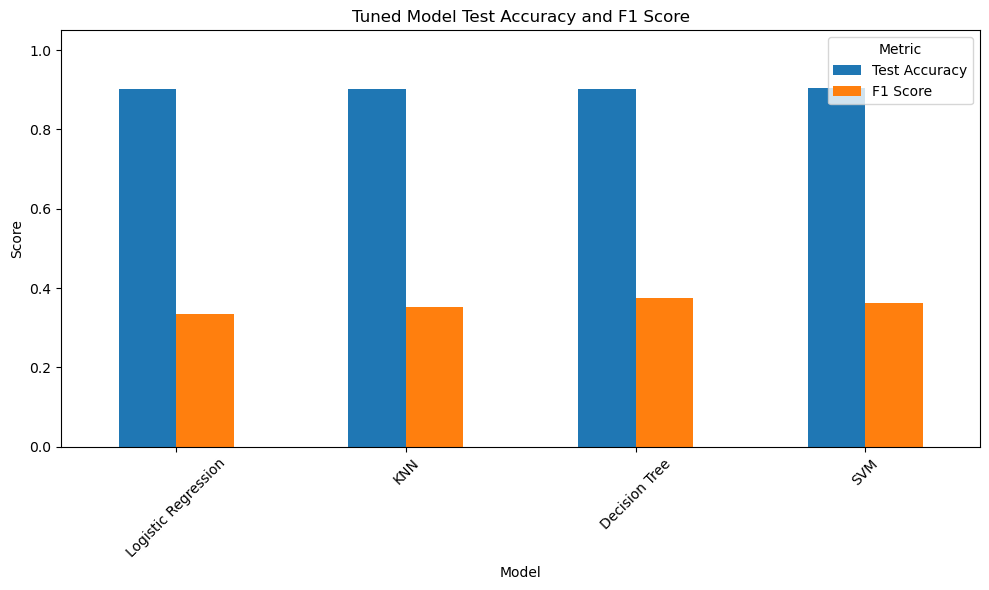

In [23]:
import matplotlib.pyplot as plt

# Use Model as the x-axis labels
results_df.plot(
    x="Model",
    y=["Test Accuracy", "F1 Score"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Tuned Model Test Accuracy and F1 Score")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

The confusion matrix contributes to the business goal by showing how well the model separates likely subscribers from unlikely subscribers. While accuracy and F1 score summarize overall performance, the confusion matrix reveals the specific types of correct and incorrect predictions. This is important because false negatives represent missed opportunities to contact customers who may have subscribed, while false positives represent marketing effort spent on customers who are less likely to respond. By reviewing the confusion matrix, the bank can better understand the tradeoff between capturing potential subscribers and reducing unnecessary campaign costs.

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7310
           1       0.68      0.26      0.38       928

    accuracy                           0.90      8238
   macro avg       0.79      0.62      0.66      8238
weighted avg       0.89      0.90      0.88      8238



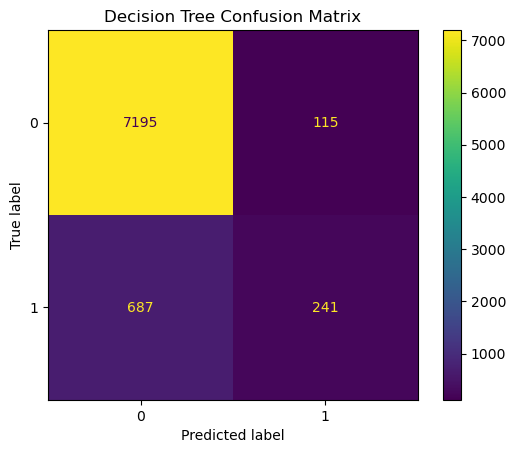

In [24]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, best_tree_preds))

ConfusionMatrixDisplay.from_estimator(
    best_tree,
    X_test,
    y_test
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

### Overall Summary

The Decision Tree best supports the business objective because it had the strongest overall performance for identifying customers who are likely to subscribe to a term deposit. It achieved the highest testing accuracy and F1 score, which means it was not only accurate overall, but also better at finding the smaller group of positive responses that are most valuable to the bank.

This ties directly to the goal of improving telephone marketing campaigns. By using the Decision Tree model, the bank could better prioritize customers who are more likely to say “yes,” reduce time spent calling customers unlikely to subscribe, and lower the chance of missing good prospects. Another benefit is that Decision Trees are easier to explain than some other models, so non-technical business stakeholders can better understand which customer or campaign features are driving the predictions.

In [28]:
# Get feature names after preprocessing
feature_names = best_tree.named_steps["transformer"].get_feature_names_out()

# Get feature importances from the decision tree model
importances = best_tree.named_steps["tree"].feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort from most important to least important
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df["Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("onehotencoder__", "", regex=False)
    .str.replace("standardscaler__", "", regex=False)
)

feature_importance_df.head(10)

,Feature,Importance
60,nr.employed,0.642837
54,pdays,0.129332
58,cons.conf.idx,0.066774
59,euribor3m,0.049317
42,month_oct,0.022902
33,contact_telephone,0.021202
49,poutcome_failure,0.015011
52,age,0.010348
45,day_of_week_mon,0.010294
56,emp.var.rate,0.010005


The Decision Tree identified nr.employed, pdays, cons.conf.idx, and euribor3m as the most important features for predicting term deposit subscription. However, these should be interpreted carefully because several of the strongest predictors are macroeconomic indicators rather than direct customer characteristics. These variables may help the bank understand when campaigns are more likely to succeed, while pdays may be more useful for deciding which customers to contact based on previous campaign history. Therefore, the bank should use these features to guide campaign timing and targeting strategy, but should not treat them as the only factors in deciding who to contact.

Overall, the tuned Decision Tree model provided the strongest balance of performance and business usefulness for this bank marketing classification problem. It produced the highest test accuracy and F1 score, suggesting that it was better than the other models at identifying customers who may subscribe to a term deposit. The analysis also showed that using accuracy alone can be misleading because the dataset is imbalanced, making F1 score and the confusion matrix important tools for understanding real campaign value. From a business perspective, the model can help the bank better prioritize future outreach, reduce inefficient calls, and understand which factors are associated with successful campaigns. However, features such as duration should be excluded from a realistic predictive model because they are only known after the call is completed. Future improvements could include testing additional performance metrics, adjusting classification thresholds, and exploring more customer-level features to make the model even more actionable for marketing decisions.